In [55]:
import numpy as np

from scipy.optimize import curve_fit, least_squares

from Fonctions.Vopt import V_opt
from Fonctions.Metriques import rsq, rmse, mae
from Fonctions.Affichage import plot_interactif

In [43]:
# Tableau : Ar-HCN
Ar = np.genfromtxt("Data/HCNAr_chinois.csv",
                   delimiter=";", names=True, dtype=None, encoding="utf-8")
# Suppression des 2 dernières lignes
Ar = Ar[:-2]


# Transformation du jeu de données pour avoir |R|Theta|E|

R_vals = Ar[Ar.dtype.names[0]]
theta_vals = np.array([float(name) for name in Ar.dtype.names[1:]])

R_col = np.repeat(R_vals, len(theta_vals))
Theta_col = np.tile(theta_vals, len(R_vals))

E_col = np.concatenate([Ar[name] for name in Ar.dtype.names[1:]]).reshape(len(theta_vals), len(R_vals)).T.ravel()

Ar_data = np.column_stack((R_col, Theta_col, E_col))

# Récupération des colonnes
R_ang = Ar_data[:, 0]
Theta_deg_inv = Ar_data[:, 1]
E_cmm1 = Ar_data[:, 2]

# Conversion des données
R_a0 = R_ang * 1.889726125
Theta_deg = 180.0 - Theta_deg_inv
E_mEh = E_cmm1 * 1000.0 / 219474.6313705
# Jeu de données converti
Ar_conv = np.array(
    list(zip(R_a0, Theta_deg, E_mEh)),
    dtype=[
        ('R', float),
        ('Theta', float),
        ('E', float)
    ]
)

In [18]:
params_opt_polonais = np.array([1.483407536976,  0.112015542111, -0.032843612191,  0.094365726134,  0.033820767387, -0.004629355901, 
                               -135783.5865435, -325692.4344777, -57995.31109569, -125784.8469770,
                                14.37087301922,  1.210291512784,  1.127352935061,  0.466341968270,  0.263961941831,  0.043692710808,
                                0.044277336958, -0.150928579110,  0.029017675752, -0.029401214750,  0.013423710578,  0.009201449094, 
                                0.008911721077,  0.050508135234, -0.008855531861,  0.013531186127, -0.008965289979, -0.005064185661,
                               -0.002917801252, -0.005428112556,  0.001146212702, -0.001178096509,  0.001834942387,  0.000752982787, 
                                0.000137627196,  0.000192853374, -0.000053626009, -0.000008219267, -0.000113691774, -0.000031076263 ])

# Méthode 1 : curve_fit

In [14]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

In [44]:
params_opt_cf, params_cov = curve_fit(V_curvefit, (R_a0, Theta_deg), E_mEh,
                                      p0=params_opt_polonais, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R_a0, Theta_deg), E_mEh,
                                      p0=params_opt_polonais, maxfev=1000000,
                                      method="lm", sigma=E_mEh)

In [45]:
print(np.array2string(
    params_opt_cf,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))
print(np.array2string(
    params_opt_cf_sigma,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))

[1.817218617675 0.589586452656 -0.418350177025 -0.241447253953
 0.408800866940 0.050118337016 -2020019.229886086658 33395893.232038579881
 -3786100.797269643284 14484966.588939419016 17.446024885596
 2.901562620985 1.279303829519 1.909706628281 3.164312074873
 0.282418077609 -0.019926055590 0.041530720581 -0.000000420044
 -0.007037507805 -0.051060359761 0.037376991796 0.016653403428
 -0.033077120394 -0.000158204528 0.007578329260 0.033968745329
 -0.025466402162 -0.003854841619 0.007499546761 0.000571225669
 -0.002254934452 -0.007692613120 0.005829248003 0.000361286583
 -0.000590664450 -0.000149555718 0.000186210577 0.000658781693
 -0.000472461499]
[1.381615485043 0.320342882500 0.000258079146 -0.005215510533
 0.074614336645 0.013966609079 -120595.585512531878 -334124.676378046977
 -36714.955698995851 -160127.720446219260 14.634755928792 3.030308503405
 2.135168583942 0.827900597628 0.703593878500 0.096162259818
 0.077862045957 -0.151407025609 0.056644543416 0.029123714114
 0.0006309443

In [46]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R_a0, Theta_deg)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R_a0, Theta_deg)

r2_cf = rsq(E_mEh, V_pred_cf)
r2_cf_sigma = rsq(E_mEh, V_pred_cf_sigma)

rmse_cf = rmse(E_mEh, V_pred_cf)
rmse_cf_sigma = rmse(E_mEh, V_pred_cf_sigma)

mae_cf = mae(E_mEh, V_pred_cf)
mae_cf_sigma = mae(E_mEh, V_pred_cf_sigma)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")

R² (sans sigma)         : 0.9998715243004014
R² (avec sigma=y)       : 0.9811865082558866

rmse (sans sigma)       : 3.0923735593795723
rmse (avec sigma=y)     : 37.421066371093296

mae (sans sigma)        : 1.2005225381377564
mae (avec sigma=y)      : 2.8428032875069364


In [47]:
np.unique(R_a0)

array([ 3.77945225,  3.87393856,  3.96842486,  4.06291117,  4.15739747,
        4.25188378,  4.34637009,  4.44085639,  4.5353427 ,  4.62982901,
        4.72431531,  4.81880162,  4.91328792,  5.00777423,  5.10226054,
        5.19674684,  5.29123315,  5.38571946,  5.48020576,  5.57469207,
        5.66917837,  5.76366468,  5.85815099,  5.95263729,  6.0471236 ,
        6.14160991,  6.23609621,  6.33058252,  6.42506882,  6.51955513,
        6.61404144,  6.70852774,  6.80301405,  6.89750036,  6.99198666,
        7.08647297,  7.18095927,  7.27544558,  7.36993189,  7.46441819,
        7.5589045 ,  7.65339081,  7.74787711,  7.84236342,  7.93684973,
        8.03133603,  8.12582234,  8.22030864,  8.31479495,  8.40928126,
        8.50376756,  8.69274017,  8.88171279,  9.0706854 ,  9.25965801,
        9.44863062,  9.63760324,  9.82657585, 10.01554846, 10.20452108,
       10.39349369, 10.5824663 , 10.77143891, 10.96041152, 11.14938414,
       11.33835675, 11.52732936, 11.71630198, 11.90527459, 12.09

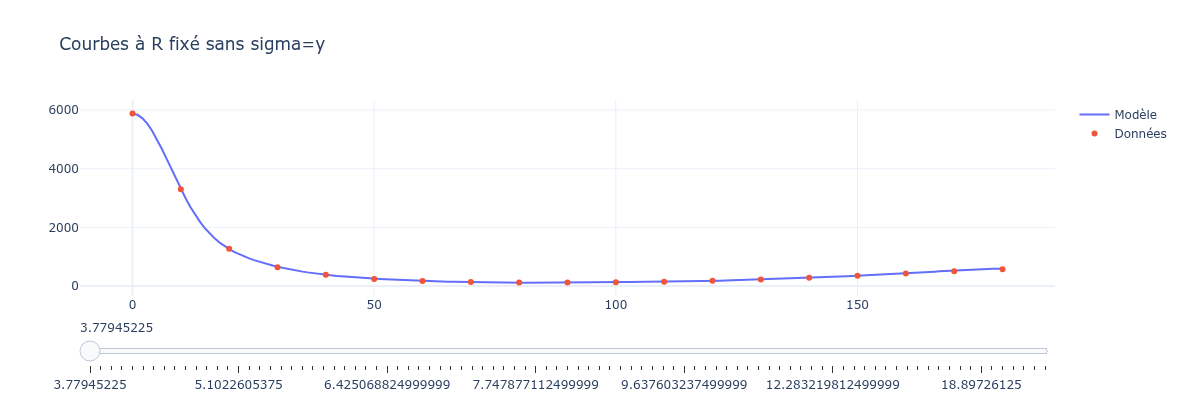

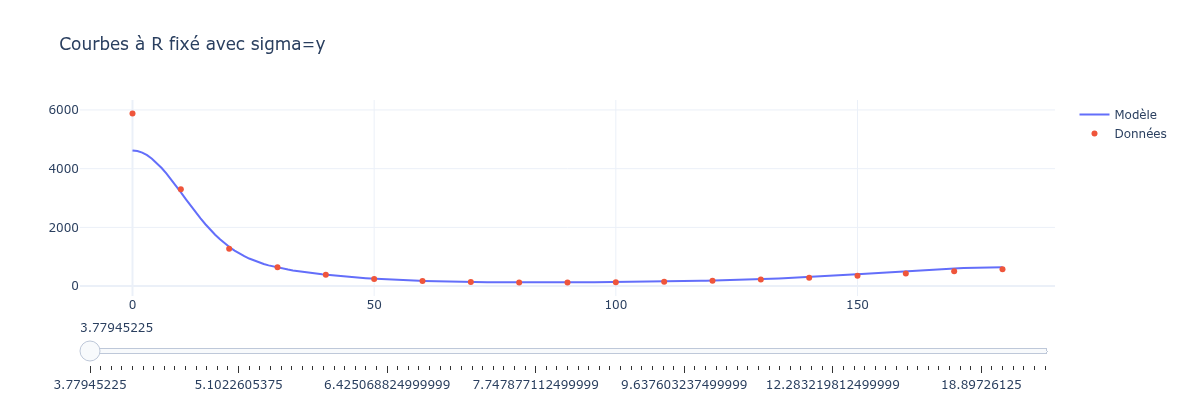

In [51]:
R_vals = np.unique(R_a0)
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, Ar_conv,
                fixed_col="R", x_col="Theta", y_col="E",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, Ar_conv,
                fixed_col="R", x_col="Theta", y_col="E",
                title="Courbes à R fixé avec sigma=y")

# Methode 2 : least_squares


In [53]:
def residus_Ar(params):
    V_pred = V_opt(params, R_a0, Theta_deg)
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - E_mEh).ravel()

In [ ]:
result1 = least_squares(residus_Ar, params_opt_polonais)
params_opt_ls = result1.x

result2 = least_squares(residus_Ar, params_opt_polonais, x_scale = "jac")
params_opt_ls_jac = result2.x

In [ ]:
result3 = least_squares(residus_Ar, params_opt_polonais, 
                        x_scale = "jac", loss="soft_l1")
params_opt_ls_jac_soft = result3.x

In [ ]:
result4 = least_squares(residus_Ar, params_opt_polonais, 
                        x_scale = "jac", loss="huber")
params_opt_ls_jac_huber = result4.x

In [ ]:
V_pred_ls = V_opt(params_opt_ls, R_a0, Theta_deg)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R_a0, Theta_deg)
V_pred_ls_jac_soft = V_opt(params_opt_ls_jac_soft, R_a0, Theta_deg)
V_pred_ls_jac_huber = V_opt(params_opt_ls_jac_huber, R_a0, Theta_deg)

r2_ls = rsq(E_mEh, V_pred_ls)
r2_ls_jac = rsq(E_mEh, V_pred_ls_jac)
r2_ls_jac_soft = rsq(E_mEh, V_pred_ls_jac_soft)
r2_ls_jac_huber = rsq(E_mEh, V_pred_ls_jac_huber)

rmse_ls = rmse(E_mEh, V_pred_ls)
rmse_ls_jac = rmse(E_mEh, V_pred_ls_jac)
rmse_ls_jac_soft = rmse(E_mEh, V_pred_ls_jac_soft)
rmse_ls_jac_huber = rmse(E_mEh, V_pred_ls_jac_huber)

mae_ls = mae(E_mEh, V_pred_ls)
mae_ls_jac = mae(E_mEh, V_pred_ls_jac)
mae_ls_jac_soft = mae(E_mEh, V_pred_ls_jac_soft)
mae_ls_jac_huber = mae(E_mEh, V_pred_ls_jac_huber)

print(f"R²                                   : {r2_ls}")
print(f"R²   (x_scale='jac')                 : {r2_ls_jac}")
print(f"R²   (x_scale='jac', 'loss=soft_l1') : {r2_ls_jac_soft}")
print(f"R²   (x_scale='jac', 'loss=huber')   : {r2_ls_jac_huber}")
print()
print(f"rmse                                 : {rmse_ls}")
print(f"rmse (x_scale='jac')                 : {rmse_ls_jac}")
print(f"rmse (x_scale='jac', loss='soft_l1') : {rmse_ls_jac_soft}")
print(f"rmse (x_scale='jac', loss='huber')   : {rmse_ls_jac_huber}")
print()
print(f"mae                                  : {mae_ls}")
print(f"mae  (x_scale='jac')                 : {mae_ls_jac}")
print(f"mae  (x_scale='jac', loss='soft_l1') : {mae_ls_jac_soft}")
print(f"mae  (x_scale='jac', loss='huber')   : {mae_ls_jac_huber}")

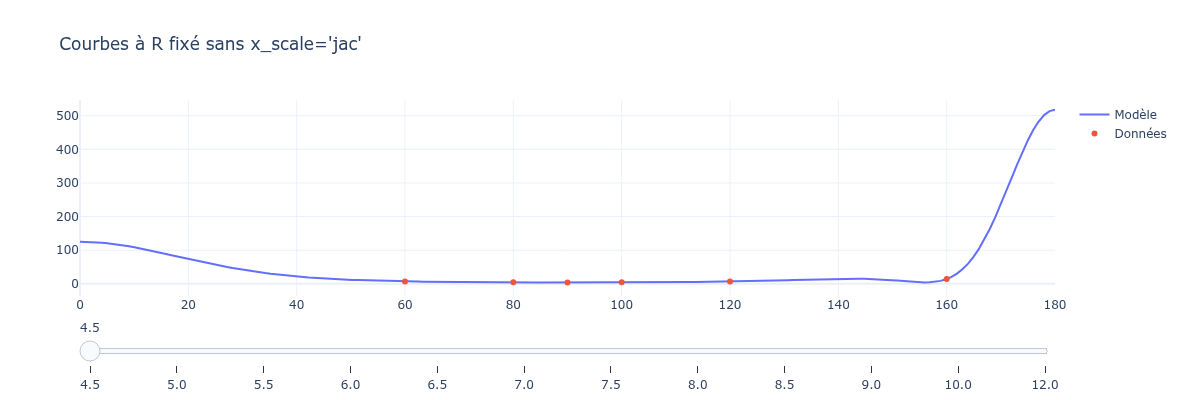

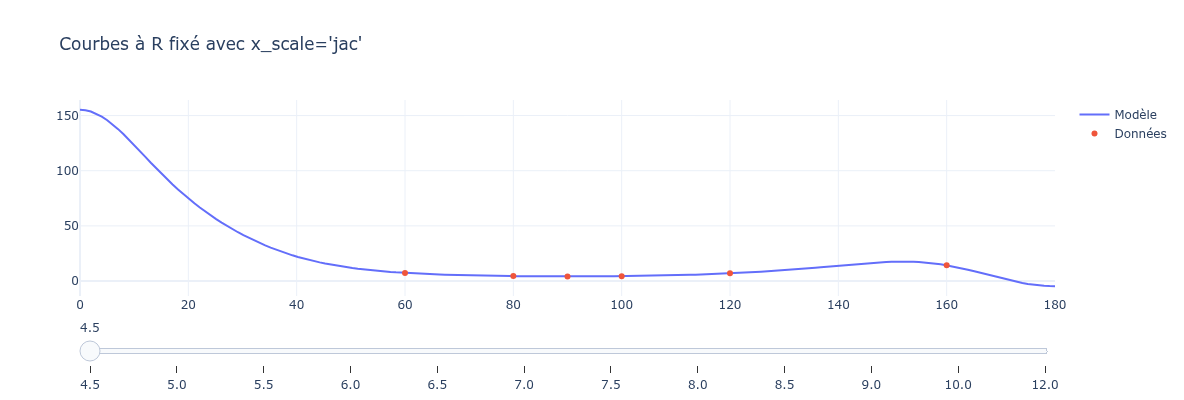

In [22]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")